# Import Libraries


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

# Load Dataset


In [2]:
df = pd.read_csv("bmw_cars_market_dataset_synthetic.csv")

# Basic Dataset Information


In [3]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(10000, 20)


In [4]:
print("First 10 Rows")
display(df.head(10))

First 10 Rows


,car_id,model,year,engine_size,horsepower,fuel_type,transmission,drivetrain,mileage_km,fuel_consumption_l_per_100km,price_usd,co2_emissions_g_km,doors,seats,body_type,color,owner_count,accident_history,service_history,country_sold
0,1,X5,2016,4.0,272,diesel,automatic,AWD,74655,8.9,66756,196.0,5,5,suv,white,2.0,no,partial,Netherlands
1,2,1 Series,2022,2.6,218,petrol,automatic,FWD,23469,8.4,26867,190.0,3,4,hatchback,black,1.0,no,partial,France
2,3,X1,2012,2.2,240,petrol,automatic,FWD,123273,7.8,31313,174.0,5,5,suv,white,3.0,no,full,Netherlands
3,4,X5,2022,3.8,316,diesel,NaN,AWD,33064,9.4,81594,192.0,5,5,suv,blue,1.0,no,NaN,France
4,5,7 Series,2023,3.1,294,petrol,automatic,RWD,23926,NaN,104105,204.0,4,5,sedan,white,1.0,no,full,Spain
5,6,X1,2010,1.9,190,diesel,automatic,AWD,182375,5.7,18615,112.0,5,5,suv,black,5.0,no,partial,France
6,7,5 Series,2008,4.2,383,petrol,automatic,AWD,274131,10.7,27173,222.0,4,5,sedan,blue,4.0,yes,partial,USA
7,8,1 Series,2017,1.7,230,petrol,automatic,RWD,73728,7.3,22374,148.0,5,5,hatchback,black,4.0,no,partial,Germany
8,9,X1,2013,1.8,171,petrol,automatic,AWD,170822,7.6,24335,166.0,5,5,suv,silver,2.0,no,full,France
9,10,i3,2012,0.0,156,electric,automatic,RWD,166379,0.0,19182,0.0,5,4,hatchback,NaN,4.0,yes,none,Spain


In [5]:
print("\nData Types:")
display(df.dtypes)


Data Types:


,0
car_id,int64
model,object
year,int64
engine_size,float64
horsepower,int64
fuel_type,object
transmission,object
drivetrain,object
mileage_km,int64
fuel_consumption_l_per_100km,float64


In [6]:
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,car_id,year,engine_size,horsepower,mileage_km,fuel_consumption_l_per_100km,price_usd,co2_emissions_g_km,doors,seats,owner_count
count,10000.00000,10000.000000,9757.000000,10000.000000,10000.000000,9754.000000,10000.000000,9775.000000,10000.000000,10000.000000,9745.000000
mean,5000.50000,2016.381700,2.484555,269.948600,112364.794000,6.568987,50861.398800,144.105678,4.319900,4.725600,1.943048
std,2886.89568,5.442478,1.201003,80.687398,86335.775989,3.021995,31131.966363,67.019864,0.774741,0.691052,1.378248
min,1.00000,2005.000000,0.000000,120.000000,0.000000,0.000000,2640.000000,0.000000,2.000000,2.000000,0.000000
25%,2500.75000,2012.000000,2.000000,211.000000,39924.000000,5.400000,29330.250000,118.000000,4.000000,5.000000,1.000000
50%,5000.50000,2017.000000,2.600000,260.000000,94483.000000,7.200000,44324.000000,157.000000,4.000000,5.000000,2.000000
75%,7500.25000,2021.000000,3.300000,317.000000,171752.750000,8.700000,63835.500000,191.000000,5.000000,5.000000,3.000000
max,10000.00000,2024.000000,5.000000,700.000000,300000.000000,12.900000,225487.000000,297.000000,5.000000,5.000000,5.000000


In [7]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   car_id                        10000 non-null  int64  
 1   model                         10000 non-null  object 
 2   year                          10000 non-null  int64  
 3   engine_size                   9757 non-null   float64
 4   horsepower                    10000 non-null  int64  
 5   fuel_type                     10000 non-null  object 
 6   transmission                  9785 non-null   object 
 7   drivetrain                    10000 non-null  object 
 8   mileage_km                    10000 non-null  int64  
 9   fuel_consumption_l_per_100km  9754 non-null   float64
 10  price_usd                     10000 non-null  int64  
 11  co2_emissions_g_km            9775 non-null   float64
 12  doors                         10000 non

# Missing Values & Duplicates


In [8]:
print("Missing Values")
display(df.isnull().sum())

Missing Values


,0
car_id,0
model,0
year,0
engine_size,243
horsepower,0
fuel_type,0
transmission,215
drivetrain,0
mileage_km,0
fuel_consumption_l_per_100km,246


In [9]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


# Missing Value Heatmap


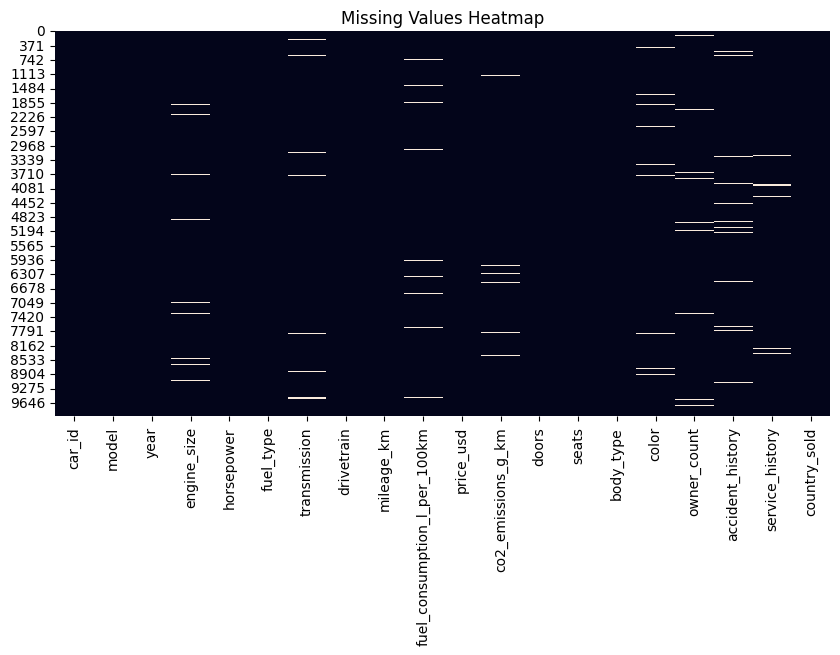

In [10]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(),
            cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

# Correlation Heatmap


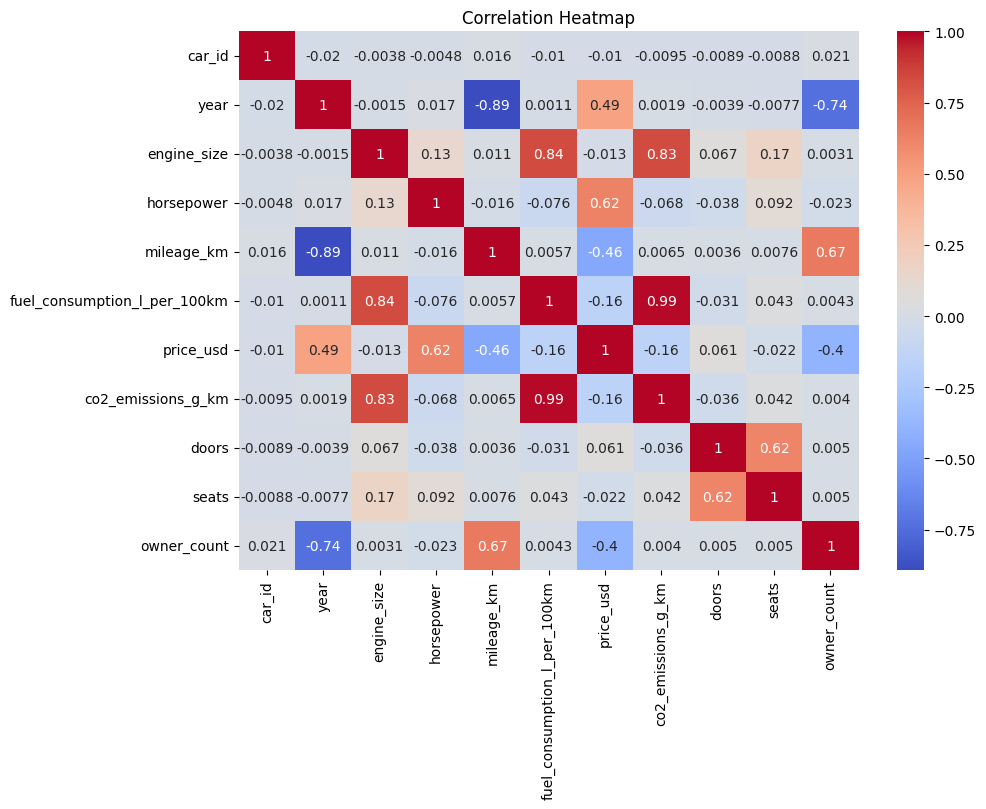

In [11]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Histograms


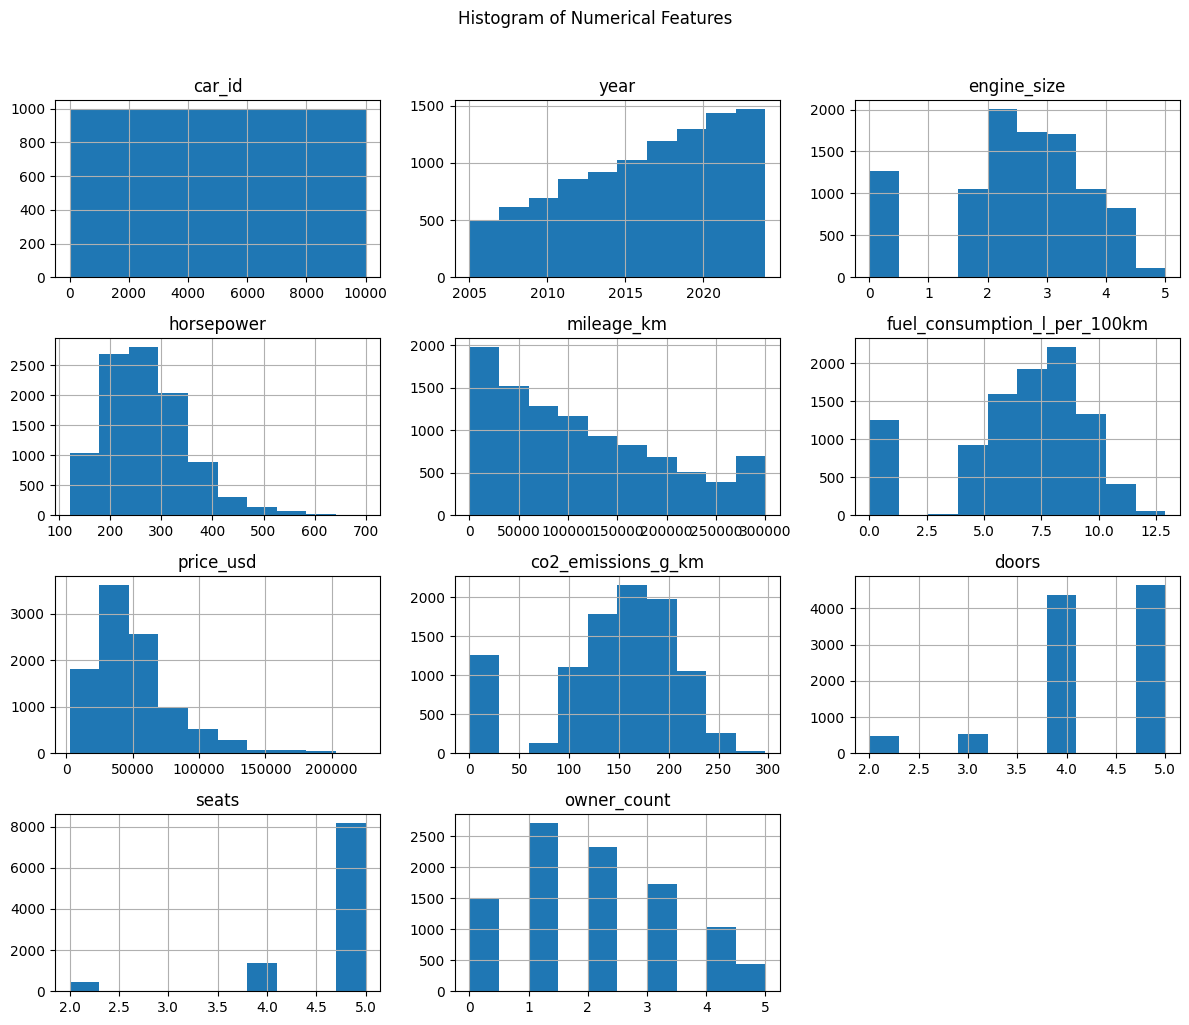

In [12]:
df.hist(
    figsize=(12,10)
)

plt.suptitle(
    "Histogram of Numerical Features",
    y=1.02
)

plt.tight_layout()

plt.show()

# Boxplots


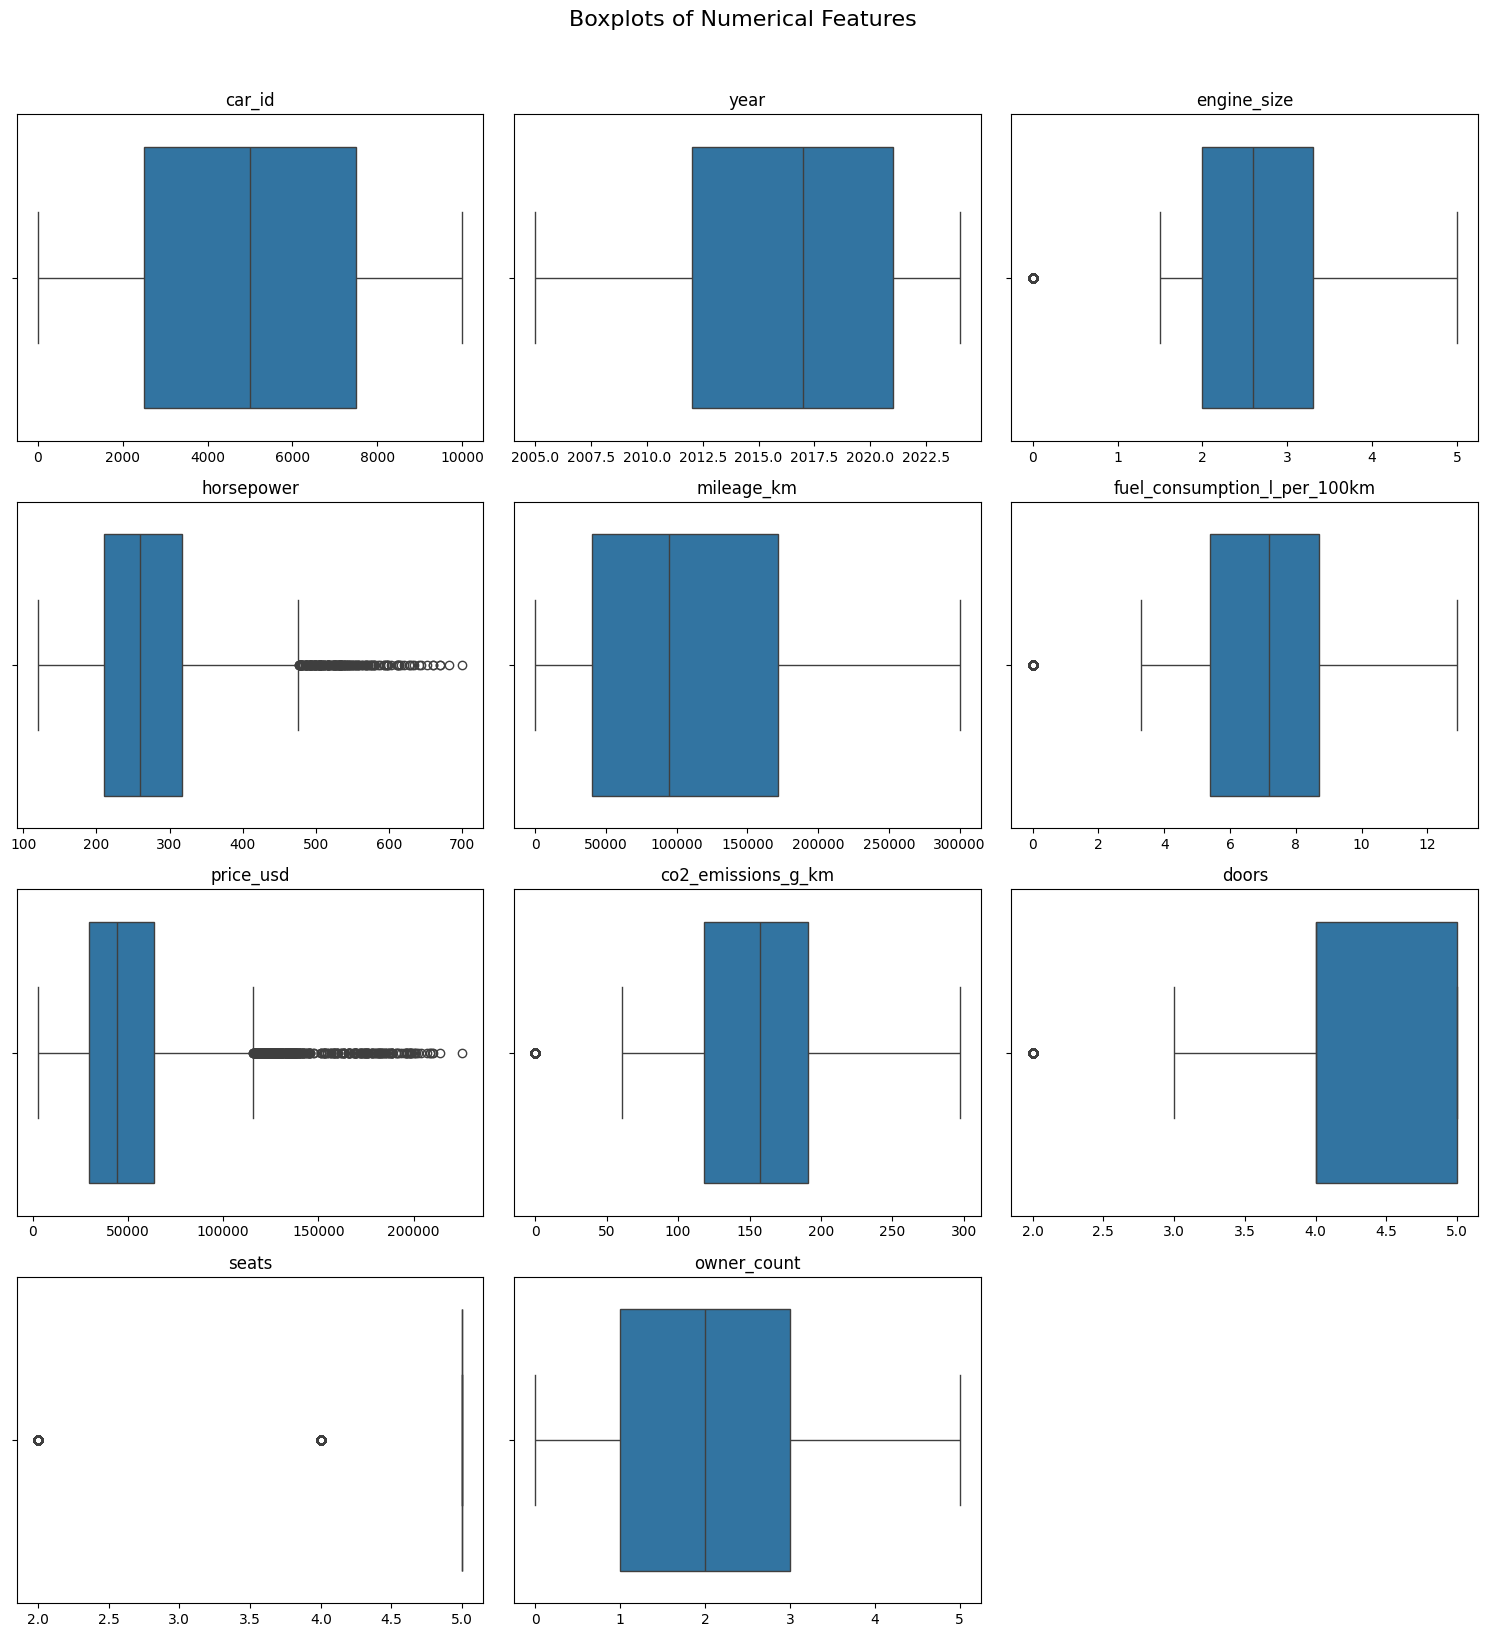

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns

n_cols = 3  # Number of columns in the grid
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.xlabel("")

plt.suptitle("Boxplots of Numerical Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Data Cleaning


In [14]:
# Remove duplicate rows
df = df.drop_duplicates()

In [15]:
# Numerical Columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

In [16]:
# Categorical Columns
cat_cols = df.select_dtypes(include="object").columns

In [17]:
# Fill Numerical Missing Values
num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [18]:
# Fill Categorical Missing Values
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [19]:
print("Missing Values After Cleaning")

display(df.isnull().sum())

Missing Values After Cleaning


,0
car_id,0
model,0
year,0
engine_size,0
horsepower,0
fuel_type,0
transmission,0
drivetrain,0
mileage_km,0
fuel_consumption_l_per_100km,0


# Save Clean Dataset


In [20]:
clean_df = df.copy()

# Feature Selection


In [21]:
target = "price_usd"

X = clean_df.drop(columns=[target])
y = clean_df[target]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10000, 19)
Target Shape: (10000,)


## Train-Test Split


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (8000, 19)
Testing Shape: (2000, 19)


# Numerical & Categorical Columns


In [23]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Numerical Features")
print(numeric_features)

print("\nCategorical Features")
print(categorical_features)

Numerical Features
Index(['car_id', 'year', 'engine_size', 'horsepower', 'mileage_km',
       'fuel_consumption_l_per_100km', 'co2_emissions_g_km', 'doors', 'seats',
       'owner_count'],
      dtype='object')

Categorical Features
Index(['model', 'fuel_type', 'transmission', 'drivetrain', 'body_type',
       'color', 'accident_history', 'service_history', 'country_sold'],
      dtype='object')


# Data Preprocessing

In [24]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            numeric_transformer,
            numeric_features
        ),

        (
            "cat",
            categorical_transformer,
            categorical_features
        )

    ]

)

## Regression Models


In [25]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42)
}

## Model Training


In [26]:
results = {}

best_model = None
best_pipeline = None
best_r2 = -1

for name, model in models.items():

    pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

    print("=" * 50)
    print(name)
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.4f}")

    if r2 > best_r2:
        best_r2 = r2
        best_model = name
        best_pipeline = pipeline

Linear Regression
MAE : 4838.33
RMSE: 7132.98
R²  : 0.9457
Decision Tree
MAE : 4876.02
RMSE: 6767.61
R²  : 0.9511
Random Forest
MAE : 3358.56
RMSE: 4715.59
R²  : 0.9763


# Model Comparison


In [27]:
results_df = pd.DataFrame(results).T

display(results_df)

,MAE,RMSE,R2 Score
Linear Regression,4838.329378,7132.983820,0.945715
Decision Tree,4876.021000,6767.607872,0.951134
Random Forest,3358.563933,4715.593902,0.976275


# R² Score Comparison


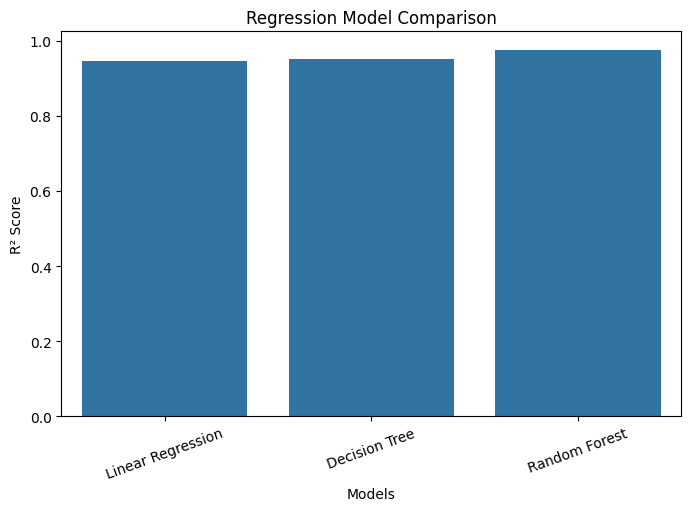

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df.reset_index(),
    x="index",
    y="R2 Score"
)

plt.title("Regression Model Comparison")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.show()

# Best Model

In [29]:
print("Best Model :", best_model)
print("Best R² Score :", best_r2)

Best Model : Random Forest
Best R² Score : 0.97627478790156


# Save


In [30]:
joblib.dump(
    best_pipeline,
    "bmw_price_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [32]:
clean_df.to_csv("bmw_cars_market_dataset_cleaned.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
